# Modeling Event Bias Contributors with Random Forest Regressor
Using a random forest regressor, we will model the contributors to event biases using different meteorological indicators and missing data flags to deduce which types of values lead to the largest event biases. 

In [20]:
import os
os.chdir('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/')

# general
import glob
import datetime as dt
from pathlib import Path

# data 
import xarray as xr 
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Configure Plotly for Jupyter notebooks
pio.renderers.default = "notebook"
# Alternative renderers you can try if "notebook" doesn't work:
# pio.renderers.default = "plotly_mimetype+notebook"
# pio.renderers.default = "jupyter_lab"

# helper tools
from metpy import calc, units
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split, GridSearchCV
from scipy.stats import randint
from pygam import LinearGAM, s, f, GammaGAM, l, te, PoissonGAM
from collections import OrderedDict 
from utils import pygam_test_dataset

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [4]:
def get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED):
    if WITH_MET and RAW_OR_NORMALIZED == "raw":
        WITH_MET = "_with_raw_met"
    elif WITH_MET and RAW_OR_NORMALIZED == "normalized":
        WITH_MET = "_with_normalized_met"
    else:
        WITH_MET = ""

    if PRODUCT == "gridded":
        PRODUCT_NAME = "_gridded"
        FOLDER_NAME = "gridded_events"
    elif PRODUCT == "events":
        PRODUCT_NAME = ""
        FOLDER_NAME = "events"
    else:
        PRODUCT_NAME = ""
    if SRC in ['asfs', 'sos']:
        SITE = 'kettle_ponds'
    elif SRC in ['bb', 'sail']:
        SITE = 'gothic'
    else:
        SITE = input("Enter site name (gothic or kettle_ponds): ")
    return DATA_DIR / SITE / f"{FOLDER_NAME}{WITH_MET}" / f"{SITE}{PRODUCT_NAME}_precipitation_event_comparisons_{SRC}{WITH_MET}.nc"

# Prepare dataset for model attempt

In [257]:
# need to get the dataset in order with variables I want and the bias value
DATA_DIR = '/storage/dlhogan/precipitation-rodeo/data/for_analysis'
# Define your root and sites
DATA_DIR = Path(DATA_DIR)
STORAGE_DIR = '/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/events'
SRC = "asfs" # one of [bb, sail, asfs, sos, '']
PRODUCT = "events" # or events
WITH_MET = True  # or True
RAW_OR_NORMALIZED = "raw"  # or raw
file_dest = get_file_destination(DATA_DIR, SRC, PRODUCT, WITH_MET, RAW_OR_NORMALIZED)
print(f"Loading data from: {file_dest}")

ds = xr.open_dataset(file_dest).sel(benchmark='billy_barr_precip')

Loading data from: /storage/dlhogan/precipitation-rodeo/data/for_analysis/kettle_ponds/events_with_raw_met/kettle_ponds_precipitation_event_comparisons_asfs_with_raw_met.nc


In [258]:
if SRC == 'sail':
    site = 'gothic'
else:
    site = 'kettle_ponds'
# get data for qc
qc_ds = xr.open_dataset(f"/storage/dlhogan/precipitation-rodeo/data/processed/final/{site}_precipitation_30min.nc")
qc_vars = [var for var in qc_ds.data_vars if 'qc' in var]
qc_ds = qc_ds[qc_vars]

In [275]:
ds.test_instrument.values

array(['billy_barr_precip', 'sail_squire_m2009_1', 'sail_squire_m2009_2',
       'sail_squire_ws2012', 'sail_squire_ws88diw', 'sos_SWE_p1',
       'sos_SWE_p2', 'sos_SWE_p3', 'sos_SWE_p4', 'splash_ld_brandes',
       'splash_ld_heymsfield', 'splash_ld_holyroyd',
       'splash_ld_unadjusted', 'splash_pluvio'], dtype='<U21')

In [276]:
instrument = 'splash_pluvio'
example_ds = ds.sel(test_instrument=instrument)
event_bad_qc_list = []
event_missing_qc_list = []
for e in example_ds.event_id.values:
    if instrument in ['sail_ld_holyroyd', 'sail_ld_heymsfield','sail_ld_brandes',]:
        qc_instrument = 'sail_ld_unadjusted'
    elif instrument in ['splash_ld_holyroyd', 'splash_ld_heymsfield','splash_ld_brandes',]:
        qc_instrument = 'splash_ld_unadjusted'
    else:
        qc_instrument = instrument
    event_bad_qc = qc_ds.sel(time=slice(example_ds.sel(event_id=e).start_time.values, example_ds.sel(event_id=e).end_time.values))[f'qc_bad_{qc_instrument}'].sum()
    event_missing_qc = qc_ds.sel(time=slice(example_ds.sel(event_id=e).start_time.values, example_ds.sel(event_id=e).end_time.values))[f'qc_missing_{qc_instrument}'].sum()
    # add values for benchmark qc
    event_bad_qc_benchmark = qc_ds.sel(time=slice(example_ds.sel(event_id=e).start_time.values, example_ds.sel(event_id=e).end_time.values))[f'qc_bad_billy_barr_precip'].sum()
    event_missing_qc_benchmark = qc_ds.sel(time=slice(example_ds.sel(event_id=e).start_time.values, example_ds.sel(event_id=e).end_time.values))[f'qc_bad_billy_barr_precip'].sum()
    event_bad_qc += event_bad_qc_benchmark
    event_missing_qc += event_missing_qc_benchmark
    event_bad_qc_list.append(event_bad_qc.values)
    event_missing_qc_list.append(event_missing_qc.values)
# add as variable
example_ds['bad_qc_count'] = (('event_id'), event_bad_qc_list)
example_ds['missing_qc_count'] = (('event_id'), event_missing_qc_list)

# if values are na, make missing qc count 1
example_ds['missing_qc_count'] = example_ds['missing_qc_count'].where(~example_ds['wind_speed_max'].isnull(),1)

# drop events with any nans
example_ds = example_ds.dropna(dim='event_id').sel(event_id=slice(0,50))  # limit to first 100 events for speed

In [277]:
y = example_ds.to_dataframe()['diff']
# perform a log transform on the target variable to improve model performance
y_trans = np.log1p(y - y.min() + 1)  # shift to make all values positive before log transform

X_cols = ['wind_speed_max',
                'pressure_min',
                'wind_speed_mean',
                'temperature_max',
                'bad_qc_count',
                'missing_qc_count',
                'temperature_min',
                # 'temperature_mean',
                'u_wind_mean']
X = example_ds.to_dataframe()[X_cols]

In [278]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_trans, test_size=0.3, random_state=42)

In [279]:
# hyperparameter tuning for RanomizedSearchCV
param_dist = {
  'n_estimators': randint(100, 500),
  'max_depth': randint(3, 15),
  'min_samples_split': randint(2, 10),
  'min_samples_leaf': randint(1, 5),
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
# Use random search to find the best hyperparameters
random_rf = RandomizedSearchCV(
  rf, param_distributions=param_dist,
  cv=10, scoring='neg_mean_squared_error',
  n_jobs=-1, verbose=False,
)
best_rf = random_rf.fit(X_train, y_train).best_estimator_
print("Best hyperparameters:", random_rf.best_params_)

# make predictions
y_pred = best_rf.predict(X_test)

# evaluate the model
# remove the max min y_test sample 
mask = (y_test != y_test.max()) & (y_test != y_test.min())
# y_test = y_test[mask]
# y_pred = y_pred[mask]
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"Mean Absolute Error: {mae}")

y_test = np.expm1(y_test) + y.min() - 1
y_pred = np.expm1(y_pred) + y.min() - 1

Best hyperparameters: {'max_depth': 11, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 368}
Mean Squared Error: 0.44467515701527793
R^2 Score: 0.011569185140766991
Mean Absolute Error: 0.5432761902274331


Text(0, 0.5, 'Relative Importance Fraction')

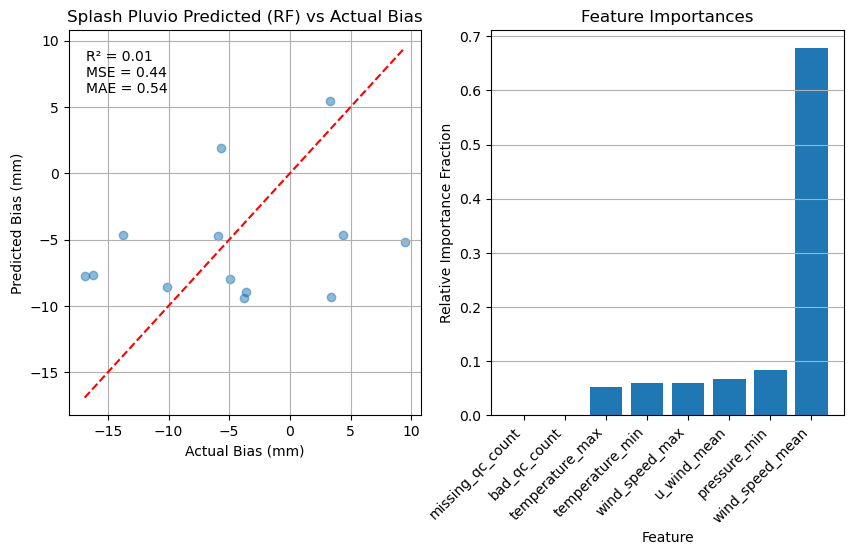

In [280]:
# plot predicted vs actual
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))

# plot predicted vs actual
axs[0].scatter(y_test, y_pred, alpha=0.5)
axs[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axs[0].set_xlabel('Actual Bias (mm)')
axs[0].set_ylabel('Predicted Bias (mm)')
axs[0].set_title(f'{instrument.replace("_", " ").title()} Predicted (RF) vs Actual Bias')
axs[0].text(0.05, 0.95, f'R² = {r2:.2f}\nMSE = {mse:.2f}\nMAE = {mae:.2f}', transform=axs[0].transAxes, verticalalignment='top')
axs[0].grid()   

# plot feature importance
importances = best_rf.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)
# plot feature importance
axs[1].set_title('Feature Importances')
axs[1].bar(range(len(indices)), importances[indices], align='center')
axs[1].grid(axis='y')
axs[1].set_xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=45, ha='right')
axs[1].set_xlabel('Feature')
axs[1].set_ylabel('Relative Importance Fraction')

### GridSearch Parameter Tuning

In [79]:
y_pred = best_rf.predict(X_test)
# evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 29.24176544520368
R^2 Score: 0.0698728163816893
Mean Absolute Error: 2.4647965364421065


In [ ]:
# hyperparameter tuning for GridSearchCV
param_dist = {
  'n_estimators': [100, 200, 300, 400, 500],
  'max_depth': [3, 5, 7, 9, 11, 13, 15],
  'min_samples_split': [2, 4, 6, 8, 10],
  'min_samples_leaf': [1, 2, 3, 4, 5]
}

# Create a random forest classifier
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Use random search to find the best hyperparameters
grid_rf = GridSearchCV(
  rf, param_grid=param_dist,
  cv=5, scoring='neg_mean_squared_error',
  n_jobs=-1, verbose=2
)

best_rf = grid_rf.fit(X_train, y_train).best_estimator_
print("Best hyperparameters:", grid_rf.best_params_)

Fitting 5 folds for each of 875 candidates, totalling 4375 fits


[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.7s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.7s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.7s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.7s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.7s


In [60]:
y_pred = best_rf.predict(X_test)

# evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print(f"Mean Absolute Error: {mae}")

Mean Squared Error: 187.5372939835674
R^2 Score: 0.3192069805390898
Mean Absolute Error: 8.301518067402345


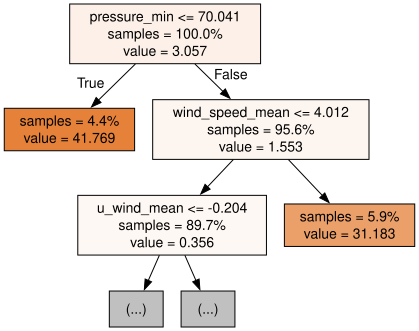

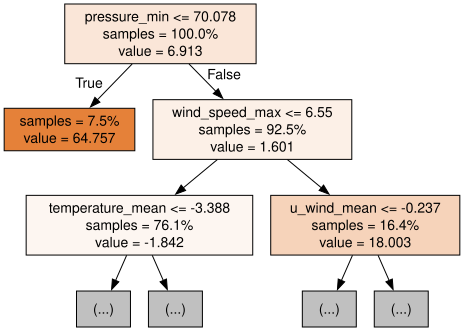

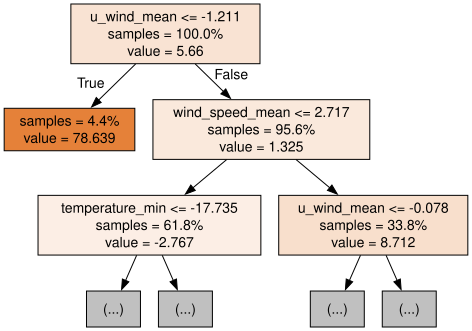

In [61]:
for i in range(3):
    tree = best_rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

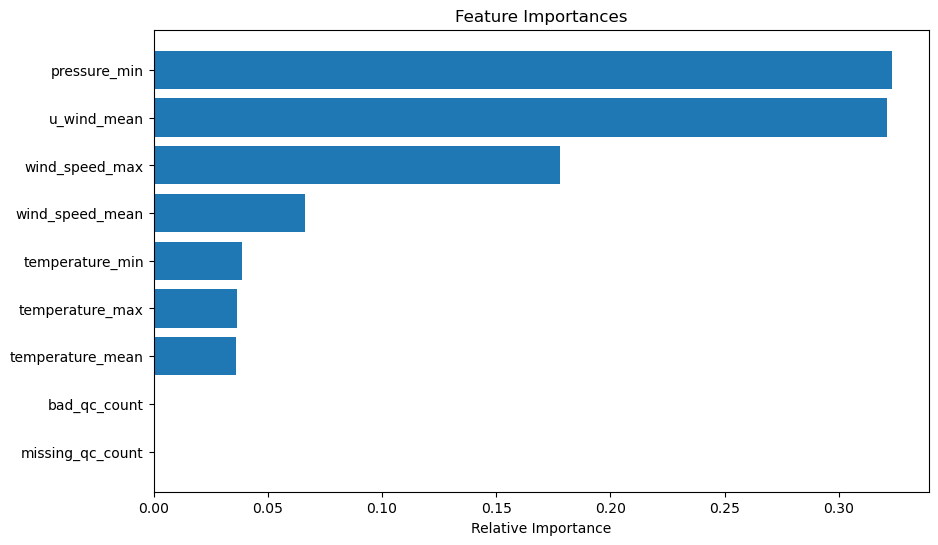

In [62]:
# plot feature importance
importances = best_rf.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()  